# **Image Reconstruction Project**

**README:**

This notebook implements a framework for reconstructing RGB images from undersampled Fourier-domain (k-space) data. Originally designed for MRI reconstruction, this implementation generalizes the approach to standard RGB image datasets (Oxford-IIIT Pet dataset).

While our project as a whole contains many more explorations of image reconstruction, we wanted to share this portion as a demo. Due to the restriction of runtime, we have reduced the number of iterations from 300 to 50 for the sake of time. This cuts the runtime greatly as the 50 iterations take less than 5 minutes to run on colab. However, if you would like to run it using the full 300, you can find and replace 'max_iter=50,' with 'max_iter=300,' instead. The difference in results is roughly 2 dB in PSNR.

In this notebook, we use the Oxford Pet Dataset.

---



This notebook features:

Multi-Image Dataset Pipeline: Loads and preprocesses RGB images into normalized tensors.

Kernel-Based Reconstruction: Implements Gaussian and Laplacian kernel basis functions for image representation.

Hyperparameter Optimization: Includes a Bayesian optimization framework (using scikit-optimize) to find the best kernel parameters (sigma, number of kernels, and TV regularization weight) based on SSIM metrics.

Comparative Metrics: Evaluates performance using MSE (Mean Squared Error), PSNR (Peak Signal-to-Noise Ratio), and SSIM (Structural Similarity Index).


In [ ]:
%%javascript
function ClickConnect(){
    console.log("Keeping alive...");
    document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect, 60000)


<IPython.core.display.Javascript object>

# Multi-Image Reconstruction from Undersampled Fourier Measurements

Here, we change the multi-image MRI reconstruction to regular RBG images.

Here is the main setup:
1. Build a multi-image RGB dataset
2. Learn shared kernel hyperparameters that work for the dataset
3. Evaluate the kernel method on held-out slices
4. Compare again zero-filled FFT baseline
5. Train residual CNN, SRCNN, U-Net, and diffusion reconstructions with Fourier-domain data consistency.

In [ ]:
!pip install torch matplotlib numpy torchmetrics scikit-optimize

import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import random
from dataclasses import dataclass
import torch.nn as nn
import torch.nn.functional as F
import shutil
import pandas as pd

import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-optimize"])
from skopt import gp_minimize
from skopt.space import Real, Integer

from PIL import Image
import requests
from io import BytesIO

In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# Preprocessing Results

Each image is converted into a normalized tensor and resized to a fixed resolution.

For general images, we keep the RGB channels and outputs a tensor of shape 3x256x256.

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize(256),     # upscale slightly
    transforms.CenterCrop(256), # consistent size
    transforms.ToTensor()
])

dataset = torchvision.datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    download=True,
    transform=transform
)

# take subset
num_images = 30
target_images = torch.stack([dataset[i][0] for i in range(num_images)], dim=0)

print(target_images.shape)  # [30, 3, 256, 256]

torch.Size([30, 3, 256, 256])


# Kernel Reconstruction

In [ ]:
def tv_loss(x, eps=1e-6):
  if x.dim() == 2:
    dx = x[1:, :] - x[:-1, :]
    dy = x[:, 1:] - x[:, :-1]
    dx = dx[:, :-1]
    dy = dy[:-1, :]
    return torch.mean(torch.sqrt(dx**2 + dy**2 + eps))

  elif x.dim() == 3:
    dx = x[:, 1:, :] - x[:, :-1, :]
    dy = x[:, :, 1:] - x[:, :, :-1]
    dx = dx[:, :, :-1]
    dy = dy[:, :-1, :]
    return torch.mean(torch.sqrt(dx**2 + dy**2 + eps))

In [ ]:
# GAUSSIAN kernel basis
def create_gaussian_kernel_basis(grid_size=256, num_kernels=1600, sigma=8.0):
    side = int(np.sqrt(num_kernels))
    assert side * side == num_kernels, "num_kernels must be a perfect square"
    x = torch.linspace(0, grid_size - 1, grid_size)
    y = torch.linspace(0, grid_size - 1, grid_size)
    grid_x, grid_y = torch.meshgrid(x, y, indexing="ij")
    coords = torch.linspace(0, grid_size - 1, side)
    centers_x, centers_y = torch.meshgrid(coords, coords, indexing="ij")
    centers_x = centers_x.flatten()
    centers_y = centers_y.flatten()
    basis = []
    for i in range(num_kernels):
        dist_sq = (grid_x - centers_x[i])**2 + (grid_y - centers_y[i])**2
        kernel = torch.exp(-dist_sq / (2 * sigma**2))
        basis.append(kernel.flatten())
    return torch.stack(basis).T


# LAPLACIAN kernel basis
def create_laplacian_kernel_basis(grid_size=256, num_kernels=1600, sigma=8.0):
    side = int(np.sqrt(num_kernels))
    assert side * side == num_kernels, "num_kernels must be a perfect square"
    x = torch.linspace(0, grid_size - 1, grid_size)
    y = torch.linspace(0, grid_size - 1, grid_size)
    grid_x, grid_y = torch.meshgrid(x, y, indexing="ij")
    coords = torch.linspace(0, grid_size - 1, side)
    centers_x, centers_y = torch.meshgrid(coords, coords, indexing="ij")
    centers_x = centers_x.flatten()
    centers_y = centers_y.flatten()
    basis = []
    for i in range(num_kernels):
        dist = torch.sqrt((grid_x - centers_x[i])**2 + (grid_y - centers_y[i])**2)
        kernel = torch.exp(-dist / sigma)
        basis.append(kernel.flatten())
    return torch.stack(basis).T


# Active kernel type set automatically after hyperparameter search
KERNEL_TYPE = "gaussian"

def create_kernel_basis(grid_size=256, num_kernels=1600, sigma=8.0):
    if KERNEL_TYPE == "gaussian":
        return create_gaussian_kernel_basis(grid_size, num_kernels, sigma)
    else:
        return create_laplacian_kernel_basis(grid_size, num_kernels, sigma)

print("Gaussian and Laplacian kernel basis functions defined.")


Gaussian and Laplacian kernel basis functions defined.


In [ ]:
# train / validation / test split over images
num_images = target_images.shape[0]
all_indices = list(range(num_images))
rng = np.random.default_rng(seed)
rng.shuffle(all_indices)

if num_images >= 6:
  train_end = max(1, int(0.70 * num_images))
  val_end = max(train_end + 1, int(0.85 * num_images))
  val_end = min(val_end, num_images - 1)

  train_indices = all_indices[:train_end]
  val_indices = all_indices[train_end:val_end]
  test_indices = all_indices[val_end:]
else:
  train_indices = all_indices[:max(1, num_images - 2)]
  val_indices = all_indices[max(1, num_images - 2):max(1, num_images - 1)]
  test_indices = all_indices[max(1, num_images - 1):]

  if len(test_indices) == 0:
      test_indices = [all_indices[-1]]
  if len(val_indices) == 0:
      val_indices = [all_indices[min(len(all_indices) - 1, 0)]]

print(f"num_images = {num_images}")
print(f"train / val / test = {len(train_indices)} / {len(val_indices)} / {len(test_indices)}")
print("train indices:", train_indices)
print("val indices:", val_indices)
print("test indices:", test_indices)

num_images = 30
train / val / test = 21 / 4 / 5
train indices: [29, 16, 7, 25, 24, 22, 5, 21, 26, 10, 19, 20, 9, 6, 18, 3, 0, 15, 17, 23, 12]
val indices: [11, 14, 28, 2]
test indices: [4, 27, 1, 13, 8]


In [ ]:
_ssim_window_cache = {}

def gaussian_window(window_size=11, sigma=1.5, channels=1, device="cpu", dtype=torch.float32):
  coords = torch.arange(window_size, device=device, dtype=dtype) - window_size // 2
  g = torch.exp(-(coords ** 2) / (2 * sigma**2))
  g = g / g.sum()
  window_2d = torch.outer(g, g)
  window_2d = window_2d / window_2d.sum()
  window = window_2d.expand(channels, 1, window_size, window_size).contiguous()
  return window

def compute_ssim(x, y, data_range=1.0, window_size=11, sigma=1.5, eps=1e-12):
  """
  x, y: [B, 1, H, W]
  returns: scalar tensor
  """
  x = x.float()
  y = y.float()

  channels = x.size(1)

  key = (window_size, sigma, channels, str(x.device), x.dtype)
  if key not in _ssim_window_cache:
    _ssim_window_cache[key] = gaussian_window(window_size, sigma, channels, x.device, x.dtype)
  window = _ssim_window_cache[key]

  mu_x = F.conv2d(x, window, padding=window_size // 2, groups=channels)
  mu_y = F.conv2d(y, window, padding=window_size // 2, groups=channels)

  mu_x2 = mu_x * mu_x
  mu_y2 = mu_y * mu_y
  mu_xy = mu_x * mu_y

  sigma_x2 = F.conv2d(x * x, window, padding=window_size // 2, groups=channels) - mu_x2
  sigma_y2 = F.conv2d(y * y, window, padding=window_size // 2, groups=channels) - mu_y2
  sigma_xy = F.conv2d(x * y, window, padding=window_size // 2, groups=channels) - mu_xy

  C1 = (0.01 * data_range) ** 2
  C2 = (0.03 * data_range) ** 2

  ssim_map = ((2 * mu_xy + C1) * (2 * sigma_xy + C2)) / (
      (mu_x2 + mu_y2 + C1) * (sigma_x2 + sigma_y2 + C2) + eps
  )

  return ssim_map.mean()

In [ ]:
# get dataset dimensions
N, C, H, W = target_images.shape

# same mask for all images and all channels to make fair hyperparameter comparisons
def create_variable_density_mask(H, W, center_fraction=0.08, accel=4.0, seed=42):
    yy, xx = torch.meshgrid(
        torch.linspace(-1.0, 1.0, H),
        torch.linspace(-1.0, 1.0, W),
        indexing="ij"
    )
    rr = torch.sqrt(xx**2 + yy**2)

    prob = 1.0 / accel + (1.0 - 1.0 / accel) * torch.exp(-6.0 * rr**2)

    center_h = max(1, int(H * center_fraction))
    center_w = max(1, int(W * center_fraction))
    h0 = H // 2 - center_h // 2
    h1 = h0 + center_h
    w0 = W // 2 - center_w // 2
    w1 = w0 + center_w

    g = torch.Generator(device="cpu")
    g.manual_seed(seed)
    random_field = torch.rand((H, W), generator=g)

    mask_real = (random_field < prob).float()
    mask_real[h0:h1, w0:w1] = 1.0
    return mask_real

mask = create_variable_density_mask(H, W, center_fraction=0.08, accel=4.0, seed=seed).to(device)
mask = mask.to(torch.complex64)

representative_test_idx = test_indices[0]
target_image = target_images[representative_test_idx].to(device)   # [C, H, W]

k_full = torch.fft.fftshift(
    torch.fft.fft2(target_image, dim=(-2, -1)),
    dim=(-2, -1)
)
y_obs = k_full * mask.unsqueeze(0)

print(f"Representative held-out test image: {representative_test_idx}")
print(f"target_images shape: {target_images.shape}")
print(f"k_full shape: {k_full.shape}")
print(f"mask shape: {mask.shape}")
print(f"y_obs shape: {y_obs.shape}")

def ifft2(k_space_data):
    return torch.fft.ifft2(
        torch.fft.ifftshift(k_space_data, dim=(-2, -1)),
        dim=(-2, -1)
    )

Representative held-out test image: 4
target_images shape: torch.Size([30, 3, 256, 256])
k_full shape: torch.Size([3, 256, 256])
mask shape: torch.Size([256, 256])
y_obs shape: torch.Size([3, 256, 256])


In [ ]:
from skopt import gp_minimize
from skopt.space import Real, Integer

class MultiImageKernelOptimizer:
    def __init__(self, target_images, mask, device="cuda"):
        self.target_images = target_images.to(device)
        self.mask = mask.to(device)
        self.device = device
        self.grid_size = target_images.shape[-1]
        self.channels = target_images.shape[1]

    def _coerce_num_kernels(self, num_kernels):
        side = max(4, int(round(np.sqrt(int(num_kernels)))))
        return side * side

    def reconstruct_single_image(self, target_image, sigma, num_kernels,
                                  lambda_tv=1e-14, max_iter=500, lr=0.01,
                                  return_history=False, kernel_type=None):
        target_image = target_image.to(self.device)   # [C, H, W]
        num_kernels = self._coerce_num_kernels(num_kernels)

        kt = kernel_type if kernel_type is not None else KERNEL_TYPE
        if kt == "laplacian":
            Phi = create_laplacian_kernel_basis(
                grid_size=self.grid_size, num_kernels=num_kernels, sigma=float(sigma)
            ).to(self.device).float()
        else:
            Phi = create_gaussian_kernel_basis(
                grid_size=self.grid_size, num_kernels=num_kernels, sigma=float(sigma)
            ).to(self.device).float()

        c = (torch.randn(num_kernels, self.channels, device=self.device) * 0.01).requires_grad_(True)
        optimizer = torch.optim.Adam([c], lr=lr)

        k_full = torch.fft.fftshift(torch.fft.fft2(target_image, dim=(-2, -1)), dim=(-2, -1))
        y_obs  = k_full * self.mask.unsqueeze(0)

        loss_history = []
        for epoch in range(max_iter):
            optimizer.zero_grad()
            x_recon = (Phi @ c).T.reshape(self.channels, self.grid_size, self.grid_size)
            k_recon = torch.fft.fftshift(torch.fft.fft2(x_recon, dim=(-2, -1)), dim=(-2, -1))
            y_recon = k_recon * self.mask.unsqueeze(0)
            data_loss = torch.mean(torch.abs(y_recon - y_obs) ** 2)
            tv = tv_loss(x_recon)
            loss = data_loss + float(lambda_tv) * tv
            loss.backward()
            optimizer.step()
            if return_history:
                loss_history.append(loss.item())

        with torch.no_grad():
            x_recon = (Phi @ c).T.reshape(self.channels, self.grid_size, self.grid_size)
            x_recon = torch.clamp(x_recon, 0.0, 1.0)
            mse  = F.mse_loss(x_recon, target_image).item()
            psnr = 10 * torch.log10(torch.tensor(1.0 / (mse + 1e-12))).item()
            # SSIM: average over channels
            ssim_val = compute_ssim(
                x_recon.unsqueeze(0),
                target_image.unsqueeze(0)
            ).item()

        out = {
            "reconstruction": x_recon.detach(),
            "mse": mse, "psnr": psnr, "ssim": ssim_val,
        }
        if return_history:
            out["loss_history"] = loss_history
        return out

    def dataset_objective(self, indices, sigma, num_kernels,
                           lambda_tv=1e-14, max_iter=75, lr=0.01,
                           kernel_type=None):
        mses, psnrs, ssims = [], [], []
        for idx in indices:
            out = self.reconstruct_single_image(
                self.target_images[idx], sigma=sigma, num_kernels=num_kernels,
                lambda_tv=lambda_tv, max_iter=max_iter, lr=lr,
                kernel_type=kernel_type,
            )
            mses.append(out["mse"])
            psnrs.append(out["psnr"])
            ssims.append(out["ssim"])
        return {"mean_mse": float(np.mean(mses)),
                "mean_psnr": float(np.mean(psnrs)),
                "mean_ssim": float(np.mean(ssims))}

    def dataset_objective_ssim(self, indices, sigma, num_kernels,
                                lambda_tv=1e-14, max_iter=75, lr=0.01,
                                kernel_type=None):
        return self.dataset_objective(indices, sigma=sigma, num_kernels=num_kernels,
                                      lambda_tv=lambda_tv, max_iter=max_iter, lr=lr,
                                      kernel_type=kernel_type)


In [ ]:


# ── Hyperparameter search skipped ─────────────────────────────────────────────
# The full Bayesian search cell is commented out above to avoid rerunning the
# slow optimization. These are the best parameters already found.

kernel_opt = MultiImageKernelOptimizer(target_images, mask, device=device)
KERNEL_TYPE      = "gaussian"
BEST_SIGMA       = 6.6805
BEST_NUM_KERNELS = 1764
BEST_LAMBDA_TV   = 2.02e-08

print("Hyperparameter search skipped; using hardcoded SSIM-optimized values.")
print(f"Using {KERNEL_TYPE.upper()} kernel: sigma={BEST_SIGMA:.4f}, "
      f"num_kernels={BEST_NUM_KERNELS}, lambda_tv={BEST_LAMBDA_TV:.2e}")

Hyperparameter search skipped; using hardcoded SSIM-optimized values.
Using GAUSSIAN kernel: sigma=6.6805, num_kernels=1764, lambda_tv=2.02e-08


In [ ]:
# BEST_SIGMA, BEST_NUM_KERNELS, BEST_LAMBDA_TV, and KERNEL_TYPE
# are all set automatically by the dual-kernel SSIM search above.
print(f"Using {KERNEL_TYPE.upper()} kernel: sigma={BEST_SIGMA:.4f}, "
      f"num_kernels={BEST_NUM_KERNELS}, lambda_tv={BEST_LAMBDA_TV:.2e}")


Using GAUSSIAN kernel: sigma=6.6805, num_kernels=1764, lambda_tv=2.02e-08


Kernel type used: GAUSSIAN
Held-out test performance (learned hyperparameters):
  mean MSE  = 0.004005
  mean PSNR = 24.102 dB
  mean SSIM = 0.6761


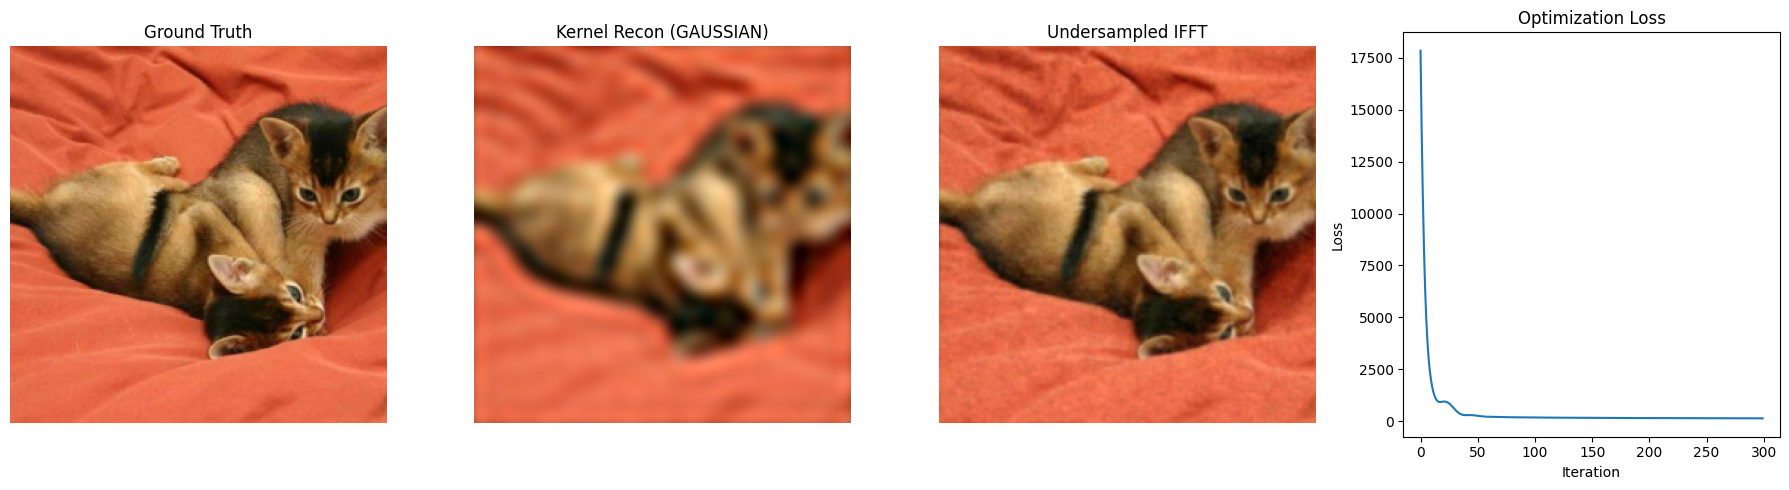

In [ ]:
def show_image_tensor(ax, img, title=""):
    img = img.detach().cpu()
    if img.dim() == 3 and img.size(0) == 3:
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
    elif img.dim() == 3 and img.size(0) == 1:
        ax.imshow(img[0], cmap="gray")
    else:
        ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

test_mses   = []
test_psnrs  = []
test_ssims  = []
test_outputs = []

for idx in test_indices:
    out = kernel_opt.reconstruct_single_image(
        target_images[idx],
        sigma=BEST_SIGMA,
        num_kernels=BEST_NUM_KERNELS,
        lambda_tv=BEST_LAMBDA_TV,
        max_iter=50,
        lr=0.01,
        return_history=(idx == representative_test_idx)
    )
    test_outputs.append((idx, out))
    test_mses.append(out["mse"])
    test_psnrs.append(out["psnr"])
    test_ssims.append(out["ssim"])

print(f"Kernel type used: {KERNEL_TYPE.upper()}")
print(f"Held-out test performance (learned hyperparameters):")
print(f"  mean MSE  = {np.mean(test_mses):.6f}")
print(f"  mean PSNR = {np.mean(test_psnrs):.3f} dB")
print(f"  mean SSIM = {np.mean(test_ssims):.4f}")

rep_out = next(out for idx, out in test_outputs if idx == representative_test_idx)
target_image = target_images[representative_test_idx].to(device)
k_full = torch.fft.fftshift(torch.fft.fft2(target_image, dim=(-2, -1)), dim=(-2, -1))
y_obs  = k_full * mask.unsqueeze(0)
final_x_recon = rep_out["reconstruction"]
loss_history  = rep_out["loss_history"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
show_image_tensor(axes[0], target_image,    "Ground Truth")
show_image_tensor(axes[1], final_x_recon,   f"Kernel Recon ({KERNEL_TYPE.upper()})")
show_image_tensor(axes[2], torch.abs(ifft2(y_obs)), "Undersampled IFFT")
axes[3].plot(loss_history)
axes[3].set_title("Optimization Loss")
axes[3].set_xlabel("Iteration")
axes[3].set_ylabel("Loss")
plt.tight_layout()
plt.show()


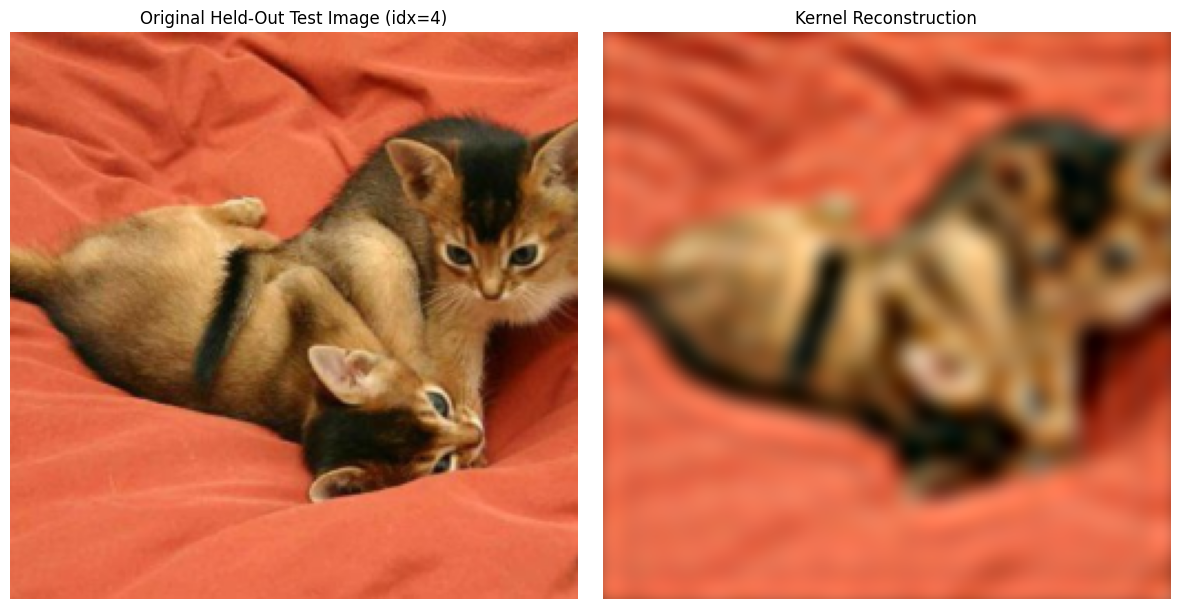

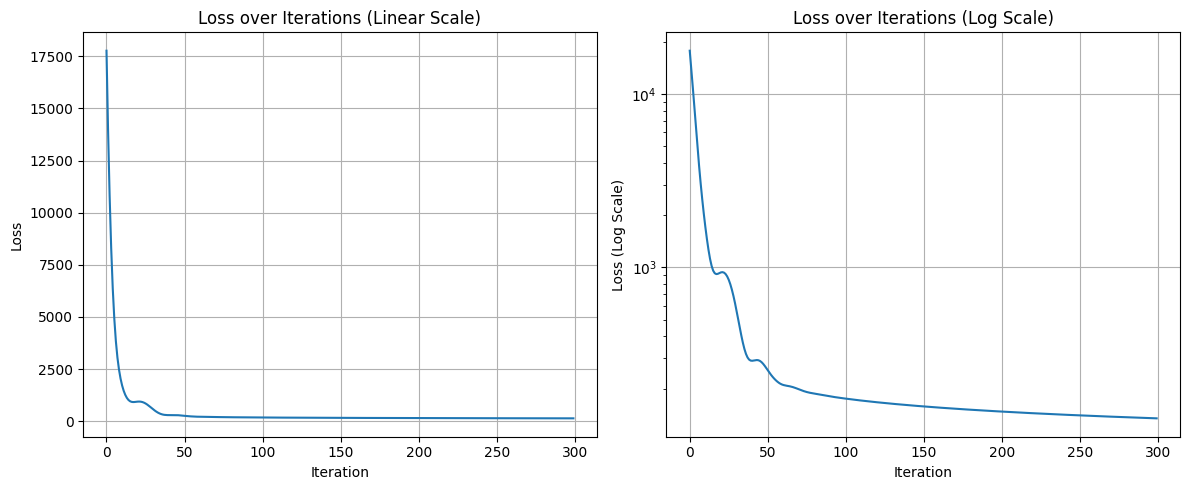

In [ ]:
representative_test_idx = test_indices[0]

out = kernel_opt.reconstruct_single_image(
    target_images[representative_test_idx],
    sigma=BEST_SIGMA,
    num_kernels=BEST_NUM_KERNELS,
    lambda_tv=BEST_LAMBDA_TV,
    max_iter=50,
    lr=0.01,
    return_history=True
)

target_image_np = target_images[representative_test_idx].detach().cpu()
reconstructed_image = out["reconstruction"].detach().cpu()
loss_history = out["loss_history"]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
show_image_tensor(
    plt.gca(),
    target_image_np,
    title=f"Original Held-Out Test Image (idx={representative_test_idx})"
)

plt.subplot(1, 2, 2)
show_image_tensor(
    plt.gca(),
    reconstructed_image,
    title="Kernel Reconstruction"
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss over Iterations (Linear Scale)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.semilogy(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss (Log Scale)")
plt.title("Loss over Iterations (Log Scale)")
plt.grid(True)

plt.tight_layout()
plt.show()

# Zero-filled FFT Reconstruction

In [ ]:
import torch
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim

def compute_metrics(pred, target):
    pred = pred.detach().cpu().float().clamp(0, 1)
    target = target.detach().cpu().float().clamp(0, 1)

    # MSE (keep as tensor first)
    mse_tensor = F.mse_loss(pred, target)

    # PSNR (now works)
    psnr = 10 * torch.log10(1.0 / (mse_tensor + 1e-12))

    # convert MSE to float after
    mse = mse_tensor.item()

    # SSIM
    pred_np = pred.squeeze().numpy()
    target_np = target.squeeze().numpy()

    if pred_np.ndim == 3:
        ssim_val = ssim(pred_np, target_np, channel_axis=0, data_range=1.0)
    else:
        ssim_val = ssim(pred_np, target_np, data_range=1.0)

    return {
        "mse": mse,
        "psnr": psnr.item(),
        "ssim": ssim_val
    }

Kernel Reconstruction MSE:  0.002706
Kernel Reconstruction PSNR: 25.68 dB
Kernel Reconstruction SSIM: 0.6950
Zero-Filled FFT MSE:  0.000851
Zero-Filled FFT PSNR: 30.70 dB
Zero-Filled FFT SSIM: 0.8828


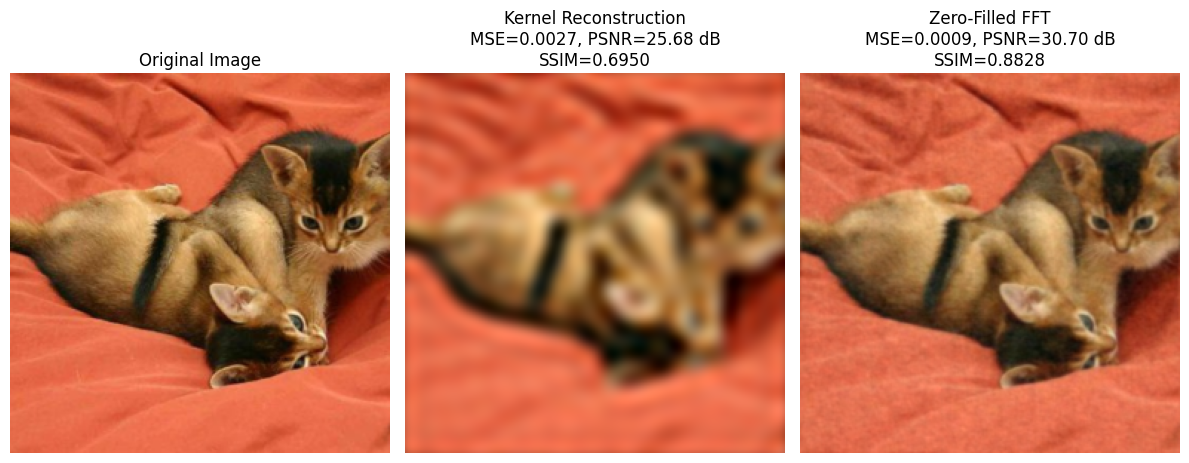

In [ ]:
y_zero_filled = torch.fft.ifft2(
    torch.fft.ifftshift(y_obs, dim=(-2, -1)),
    dim=(-2, -1)
)

x_zf = torch.real(y_zero_filled)

# clamp to display range
x_zf = x_zf - x_zf.min()
x_zf = x_zf / (x_zf.max() + 1e-12)

# metrics for both reconstructions
kernel_metrics = compute_metrics(final_x_recon, target_image)
zf_metrics = compute_metrics(x_zf, target_image)

print(f"Kernel Reconstruction MSE:  {kernel_metrics['mse']:.6f}")
print(f"Kernel Reconstruction PSNR: {kernel_metrics['psnr']:.2f} dB")
print(f"Kernel Reconstruction SSIM: {kernel_metrics['ssim']:.4f}")

print(f"Zero-Filled FFT MSE:  {zf_metrics['mse']:.6f}")
print(f"Zero-Filled FFT PSNR: {zf_metrics['psnr']:.2f} dB")
print(f"Zero-Filled FFT SSIM: {zf_metrics['ssim']:.4f}")

# convert from [3, H, W] -> [H, W, 3]
target_np = target_image.detach().cpu().permute(1, 2, 0).numpy()
kernel_np = final_x_recon.detach().cpu().permute(1, 2, 0).numpy()
zf_np = x_zf.detach().cpu().permute(1, 2, 0).numpy()

target_np = np.clip(target_np, 0, 1)
kernel_np = np.clip(kernel_np, 0, 1)
zf_np = np.clip(zf_np, 0, 1)

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(target_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(kernel_np)
plt.title(f"Kernel Reconstruction\nMSE={kernel_metrics['mse']:.4f}, PSNR={kernel_metrics['psnr']:.2f} dB\nSSIM={kernel_metrics['ssim']:.4f}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(zf_np)
plt.title(f"Zero-Filled FFT\nMSE={zf_metrics['mse']:.4f}, PSNR={zf_metrics['psnr']:.2f} dB\nSSIM={zf_metrics['ssim']:.4f}")
plt.axis("off")

plt.tight_layout()
plt.show()



In [ ]:
# evaluate zero-filled FFT baseline

zf_mses = []
zf_psnrs = []
zf_ssims = []
zf_outputs = []

for idx in test_indices:
    target_image = target_images[idx].to(device)   # [C, H, W]

    # simulate undersampled k-space
    y_full = torch.fft.fftshift(
        torch.fft.fft2(target_image, dim=(-2, -1)),
        dim=(-2, -1)
    )
    y_obs = y_full * mask.to(device).unsqueeze(0)

    # zero-filled inverse FFT reconstruction
    y_zero_filled = torch.fft.ifft2(
        torch.fft.ifftshift(y_obs, dim=(-2, -1)),
        dim=(-2, -1)
    )

    x_zf = torch.real(y_zero_filled)

    # normalize each reconstructed image to [0, 1]
    x_zf = x_zf - x_zf.min()
    x_zf = x_zf / (x_zf.max() + 1e-12)

    # compute all metrics
    metrics_zf = compute_metrics(x_zf, target_image)

    zf_mses.append(metrics_zf["mse"])
    zf_psnrs.append(metrics_zf["psnr"])
    zf_ssims.append(metrics_zf["ssim"])
    zf_outputs.append((idx, x_zf.detach().cpu()))

# aggregate test performance
mean_mse_zf = np.mean(zf_mses)
mean_psnr_zf = np.mean(zf_psnrs)
mean_ssim_zf = np.mean(zf_ssims)

print("Zero-Filled FFT Test Performance")
print(f"Mean MSE:  {mean_mse_zf:.6f}")
print(f"Mean PSNR: {mean_psnr_zf:.2f} dB")
print(f"Mean SSIM: {mean_ssim_zf:.4f}")



Zero-Filled FFT Test Performance
Mean MSE:  0.002501
Mean PSNR: 26.46 dB
Mean SSIM: 0.7875
